In [9]:

import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.preprocessing import image
import os


In [10]:
os.chdir("/home/ryu/code/DL_project")

MODEL_PATH = "models/cnn_v1.h5"

model = tf.keras.models.load_model(MODEL_PATH)

# build model
dummy = tf.zeros((1,224,224,3))
_ = model(dummy)

print("Model loaded")


Model loaded


In [11]:
CLASS_NAMES = ['glioma', 'meningioma', 'no-tumor', 'pituitary']


In [12]:
def predict_image(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    pred = model.predict(img_array, verbose=0)

    class_index = np.argmax(pred)
    confidence = float(np.max(pred))

    return CLASS_NAMES[class_index], confidence


In [ ]:
TEST_DIR = "datasets/BT-MRI/test"

results = []

for class_name in CLASS_NAMES:

    class_dir = os.path.join(TEST_DIR, class_name)

    for img_name in os.listdir(class_dir):

        img_path = os.path.join(class_dir, img_name)

        pred_class, confidence = predict_image(img_path)

        results.append({
            "image": img_name,
            "actual": class_name,
            "predicted": pred_class,
            "confidence": confidence
        })

print("Prediction complete")


In [ ]:
df = pd.DataFrame(results)

SAVE_PATH = "outputs/predictions/cnn_predictions.csv"

df.to_csv(SAVE_PATH, index=False)

print("Saved:", SAVE_PATH)

df.head()


Saved: outputs/predictions/mobilenet_predictions.csv


,image,actual,predicted,confidence
0,BT-MRI Test GL (281).jpg,glioma,glioma,0.950963
1,BT-MRI Test GL (191).jpg,glioma,glioma,0.992649
2,BT-MRI Test GL (84).jpg,glioma,glioma,0.996756
3,BT-MRI Test GL (71).jpg,glioma,glioma,0.988839
4,BT-MRI Test GL (129).jpg,glioma,glioma,0.999726


In [ ]:
correct = (df["actual"] == df["predicted"]).sum()
total = len(df)

accuracy = correct / total

print("Total:", total)
print("Correct:", correct)
print("Accuracy:", accuracy)


Total: 1311
Correct: 1194
Accuracy: 0.9107551487414187


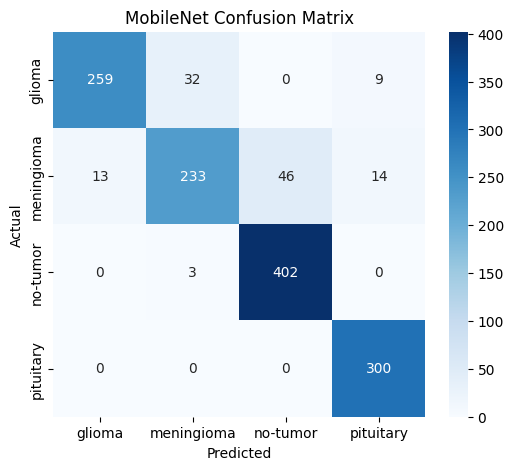

Saved: outputs/metrics/mobilenet_confusion_matrix.png


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(df["actual"], df["predicted"], labels=CLASS_NAMES)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap="Blues"
)

plt.title("MobileNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

SAVE_PATH = "outputs/metrics/mobilenet_confusion_matrix.png"

plt.savefig(SAVE_PATH)
plt.show()

print("Saved:", SAVE_PATH)
